In [1]:
# Make the repo importable from this notebook (it lives in <repo>/jupyternotebooks) and provide what
# `source setup.sh` would give a shell: Jupyter kernels do not source it.
import os, sys
from pathlib import Path
from tqdm import tqdm

REPO = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "setup.sh").is_file()),
    Path("/global/homes/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae"),
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# configs/file_dict.py needs LOCAL_BASE_DIR; take it from setup.sh if the kernel does not have it
if "LOCAL_BASE_DIR" not in os.environ:
    for line in (REPO / "setup.sh").read_text().splitlines():
        if line.startswith("export LOCAL_BASE_DIR="):
            os.environ["LOCAL_BASE_DIR"] = line.split("=", 1)[1].strip().strip('"').strip("'")

print("repo:", REPO, "\nLOCAL_BASE_DIR:", os.environ["LOCAL_BASE_DIR"])

import copy
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.optim import AdamW

from src.processing import process_delphes_events, build_arrays, presence_mask, FEATURES, VALID
from src.processing import compute_normalization, apply_normalization, invert_normalization, build_interaction_norm

from src.model.dpt_model import DPTDataSet, DPTModel, GpuBatchLoader
from src.model.loss import compute_loss, supervised_contrastive_loss

repo: /global/u2/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae 
LOCAL_BASE_DIR: /pscratch/sd/d/dnoll/projects/haxad/EventGenDelphes/output/


In [2]:
num_events_per_process = 200_000

# every SM background and every signal mass point in configs/file_dict.py; the contrastive loss uses group_id,
# so the mass points of one signal family count as one class
processes = [
    "ggh_yy", "vbf_yy", "vh_yy", "ttH_yy",
    "WN_HyyN_150", "WN_HyyN_200", "WN_HyyN_600",
    "Hl_Hyyl_150", "Hl_Hyyl_300", "Hl_Hyyl_450",
    "TT_tZNtHyyN_500_180_50", "TT_tZNtHyyN_1000_205_60", "TT_tZNtHyyN_1200_205_60",
    "HVT_VcXjjHyy_500_10", "HVT_VcXjjHyy_500_300", "HVT_VcXjjHyy_2000_300", "HVT_VcXjjHyy_2000_1700",
]
combined_df = pd.concat(
    [process_delphes_events("nonres_yy_jjj", num_events_per_process=1_000_000)]
    + [process_delphes_events(p, num_events_per_process=num_events_per_process) for p in processes],
    ignore_index=True,
)

# shuffle the combined dataframe to avoid any ordering bias
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# particle_level (n, 13, 7), kin_raw (n, 13, 4), process_id (n,), group_id (n,), event_weight (n,); pair features are built per batch from kin_raw
arrays = build_arrays(combined_df)

normalization_params = compute_normalization(arrays)
arrays_normalized = apply_normalization(arrays, normalization_params)



In [3]:
LATENT_DIM = 8
NUM_SELF_ATTN_LAYERS = 4
NUM_CLASS_ATTN_LAYERS = 2
NUM_HEADS = 8
EXPANSION = 3
DROP_RATE = 0.1
STOCHASTIC_DEPTH_DROP_RATE = 0.1
EMBEDDING_DIM = 128
CONV_EMBED_LATENT_DIM = 128
NUM_CONV_LAYERS = 2
NUM_EMBEDDING_LAYERS = 2
LAYER_SCALE_INI_VAL = 1e-4

NUM_PARTICLES = arrays_normalized["particle_level"].shape[1]
NUM_PARTICLE_FEATURES = arrays_normalized["particle_level"].shape[2]
NUM_INTERACTION_FEATURES = 6
INPUT_SHAPE =     (
    (NUM_PARTICLES, NUM_PARTICLE_FEATURES),
    (NUM_PARTICLES, NUM_PARTICLES, NUM_INTERACTION_FEATURES),
)


autoencoder_model = DPTModel(
    input_shape=INPUT_SHAPE,
    latent_dim=LATENT_DIM,
    num_self_attn_layers=NUM_SELF_ATTN_LAYERS,
    num_class_attn_layers=NUM_CLASS_ATTN_LAYERS,
    num_heads=NUM_HEADS,
    expansion=EXPANSION,
    layer_scale_ini_val=LAYER_SCALE_INI_VAL,
    drop_rate=DROP_RATE,
    stochastic_depth_drop_rate=STOCHASTIC_DEPTH_DROP_RATE,
    embedding_dim=EMBEDDING_DIM,
    num_embeding_layers=NUM_EMBEDDING_LAYERS,
    conv_embed_latent_dim=CONV_EMBED_LATENT_DIM,
    num_conv_layers=NUM_CONV_LAYERS,
    use_rmsnorm=False,
    use_qknorm=False,
    interaction_norm_type="layernorm",
)

autoencoder_model.to("cuda" if torch.cuda.is_available() else "cpu")

print("num params:", sum(p.numel() for p in autoencoder_model.parameters() if p.requires_grad))

num params: 1786708


In [4]:
# 80 / 20 train / validation split. combined_df was shuffled above, so contiguous slices are random samples.
device = "cuda" if torch.cuda.is_available() else "cpu"
n_events = len(arrays_normalized["process_id"])
n_train = int(0.8 * n_events)


def make_dataset(rows):
    return DPTDataSet(
        particle_level=arrays_normalized["particle_level"][rows],
        kin_raw=arrays_normalized["kin_raw"][rows],                          # raw pt, eta, phi, m: the pair features are built per batch from these
        mask_data=presence_mask(arrays_normalized["particle_level"][rows]),  # 1 where the object exists
        process_id=arrays_normalized["process_id"][rows],
        group_id=arrays_normalized["group_id"][rows],                        # haxad contrastive group: signal mass points share one
        device=device,
        interaction_norm=build_interaction_norm(normalization_params),       # [(type, mean, std), ...] applied to the pair features per batch
    )


train_dataset = make_dataset(slice(0, n_train))
val_dataset = make_dataset(slice(n_train, n_events))

# balanced sampling for training AND validation: every contrastive group gets the same share of each batch
# (weight = 1 / its event count), drawn with replacement like haxad's weighted loader. Without it 88% of every batch
# is nonres, which dominates both the contrastive anchors and the reconstruction fit; balancing the validation batches
# too puts the logged contrastive value on the same floor as in training (~log(batch / n_groups)).
def group_balanced_weights(rows):
    _, inverse, counts = np.unique(arrays_normalized["group_id"][rows], return_inverse=True, return_counts=True)
    return 1.0 / counts[inverse]


train_dataloader = GpuBatchLoader(train_dataset, batch_size=8192, weights=group_balanced_weights(slice(0, n_train)))  # whole-batch gather on the device; torch DataLoader is 30-500x slower here
val_dataloader = GpuBatchLoader(val_dataset, batch_size=8192, weights=group_balanced_weights(slice(n_train, n_events)))
print(f"train: {len(train_dataset)} events in {len(train_dataloader)} batches | val: {len(val_dataset)} events in {len(val_dataloader)} batches | device: {device}")

train: 3520000 events in 429 batches | val: 880000 events in 107 batches | device: cuda


In [5]:
load_weights = False

if load_weights:
    WEIGHTS_DIR = REPO / "model_weights"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    checkpoint = torch.load(WEIGHTS_DIR / "contrastive_autoencoder.pt", map_location=device)
    autoencoder_model = DPTModel(**checkpoint["config"]).to(device)
    autoencoder_model.load_state_dict(checkpoint["state_dict"])
    autoencoder_model.eval()
    
    print("loaded", sum(p.numel() for p in autoencoder_model.parameters()), "params from", WEIGHTS_DIR)

loaded 1786708 params from /global/u2/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae/model_weights


/tmp/ipykernel_2353413/3272884341.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(WEIGHTS_DIR / "contrastive_autoencoder.pt", map_location=device

In [6]:
epochs = 100
early_stopping_patience = 10
initial_lr = 1e-4
warmup_epochs = 10  # linear warm-up of the lr from ~0 to initial_lr
min_lr = 1e-6       # floor of the cosine decay, reached at the last epoch (haxad ETA_MIN)
grad_clip = 20.0    # clip_grad_norm_ threshold (haxad GRAD_CLIP): above the natural grad-norm scale, so it only catches spikes
lambda_c = 1.0      # weight of the supervised contrastive term relative to the reconstruction loss (mse + presence bce)

# haxad's speed-ups: TF32 matmuls (1.3x) and torch.compile (2.7x per training step, ~2 min one-time compile at the
# first step). Training runs through compiled_model; validation, state_dict and checkpoints use the eager
# autoencoder_model, which shares the weights, so nothing carries torch.compile's `_orig_mod.` prefix and the
# eval-mode graph and the odd-sized last validation batch never trigger extra compilations.
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(autoencoder_model, dynamic=False) if device == "cuda" else autoencoder_model

valid = torch.as_tensor(VALID, device=device)  # (13, 7): which feature is defined for which slot, weights the reconstruction loss
optimizer = AdamW(autoencoder_model.parameters(), lr=initial_lr)

# lr schedule, stepped once per batch: linear warm-up over warmup_epochs, then cosine decay to min_lr
steps_per_epoch = len(train_dataloader)
warmup_steps, total_steps = warmup_epochs * steps_per_epoch, epochs * steps_per_epoch


def lr_factor(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr / initial_lr + (1 - min_lr / initial_lr) * 0.5 * (1 + math.cos(math.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)


def run_epoch(model, dataloader, optimizer=None, scheduler=None):
    """One pass over the loader: a training pass when an optimizer is given, an evaluation pass otherwise.
    Returns the batch-averaged loss, mse and bce, the per-feature mse (list of 7) and, when training,
    the mean and max gradient norm before clipping."""
    model.train(optimizer is not None)
    totals = {"loss": 0.0, "mse": 0.0, "bce": 0.0, "contrastive_loss": 0.0, "mse_per_feature": torch.zeros(NUM_PARTICLE_FEATURES, device=device)}
    grad_norms = []
    with torch.set_grad_enabled(optimizer is not None):
        for particle_level, interaction, mask, process_id, group_id in dataloader:
            reco, presence_logits, z = model((particle_level, interaction, mask))

            contrastive_projection = model.contrastive_projection(z)

            loss, components = compute_loss(reco, presence_logits, particle_level, mask, valid)

            contrastive_loss = supervised_contrastive_loss(contrastive_projection, group_id.view(-1, 1))  # (B, 1) group labels: same group = positive pair
            loss = loss + lambda_c * contrastive_loss

            if optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                grad_norms.append(torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip).item())  # the norm BEFORE clipping
                optimizer.step()
                scheduler.step()
            totals["loss"] += loss.item()
            totals["mse"] += components["mse"].item()
            totals["bce"] += components["bce"].item()
            totals["contrastive_loss"] += contrastive_loss.item()
            totals["mse_per_feature"] += components["mse_per_feature"]
    n = len(dataloader)
    result = {"loss": totals["loss"] / n, "mse": totals["mse"] / n, "bce": totals["bce"] / n,
              "contrastive_loss": totals["contrastive_loss"] / n, "mse_per_feature": (totals["mse_per_feature"] / n).tolist()}
    if grad_norms:
        result["grad_norm_mean"], result["grad_norm_max"] = float(np.mean(grad_norms)), float(np.max(grad_norms))
    return result


history = {"train": [], "val": []}
best_val, best_state, epochs_without_improvement = float("inf"), None, 0

for epoch in tqdm(range(epochs), desc="training", unit="epoch"):
    train = run_epoch(compiled_model, train_dataloader, optimizer, scheduler)
    val = run_epoch(autoencoder_model, val_dataloader)
    history["train"].append(train)
    history["val"].append(val)

    per_feature = " ".join(f"{name} {value:.3f}" for name, value in zip(FEATURES, val["mse_per_feature"]))
    tqdm.write(f"epoch {epoch + 1:3d} | train {train['loss']:.4f} | val {val['loss']:.4f} (mse {val['mse']:.4f}, bce {val['bce']:.4f}, contrastive {val['contrastive_loss']:.4f}) "
               f"| lr {optimizer.param_groups[0]['lr']:.1e} | grad norm {train['grad_norm_mean']:.1f} (max {train['grad_norm_max']:.1f}) "
               f"| val mse per feature: {per_feature}")

    if val["loss"] < best_val:
        best_val, best_state, epochs_without_improvement = val["loss"], copy.deepcopy(autoencoder_model.state_dict()), 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            tqdm.write(f"early stopping: no improvement for {early_stopping_patience} epochs")
            break

autoencoder_model.load_state_dict(best_state)  # keep the weights of the best validation epoch
print(f"best val loss {best_val:.4f} after {len(history['val'])} epochs")

training:   1%|          | 1/100 [02:47<4:35:50, 167.18s/epoch]

epoch   1 | train 11.5363 | val 11.0860 (mse 1.7169, bce 0.6710, contrastive 8.6982) | lr 1.0e-05 | grad norm 2.0 (max 7.2) | val mse per feature: pt 0.712 eta 1.496 phi 3.306 m 0.968 btag 0.628 tau32 0.533 tau43 0.547


training:   2%|▏         | 2/100 [04:02<3:04:32, 112.98s/epoch]

epoch   2 | train 10.3460 | val 9.7710 (mse 0.7550, bce 0.5770, contrastive 8.4391) | lr 2.0e-05 | grad norm 10.7 (max 51.8) | val mse per feature: pt 0.200 eta 0.979 phi 1.548 m 0.897 btag 0.450 tau32 0.068 tau43 0.082


training:   3%|▎         | 3/100 [05:17<2:34:38, 95.66s/epoch] 

...

epoch  98 | train 8.3574 | val 8.3165 (mse 0.2065, bce 0.0225, contrastive 8.0875) | lr 1.1e-06 | grad norm 3.9 (max 36.8) | val mse per feature: pt 0.115 eta 0.446 phi 0.283 m 0.447 btag 0.307 tau32 0.036 tau43 0.039


training:  99%|█████████▉| 99/100 [2:05:18<01:14, 74.98s/epoch]

epoch  99 | train 8.3577 | val 8.3154 (mse 0.2073, bce 0.0226, contrastive 8.0855) | lr 1.0e-06 | grad norm 4.1 (max 64.3) | val mse per feature: pt 0.115 eta 0.448 phi 0.284 m 0.447 btag 0.307 tau32 0.036 tau43 0.039


training: 100%|██████████| 100/100 [2:06:33<00:00, 75.94s/epoch]

epoch 100 | train 8.3562 | val 8.3167 (mse 0.2065, bce 0.0225, contrastive 8.0876) | lr 1.0e-06 | grad norm 3.8 (max 39.0) | val mse per feature: pt 0.114 eta 0.447 phi 0.283 m 0.448 btag 0.306 tau32 0.036 tau43 0.039
best val loss 8.3147 after 100 epochs


In [6]:
WEIGHTS_DIR = REPO / "model_weights"
WEIGHTS_DIR.mkdir(exist_ok=True)

model_config = dict(
    input_shape=INPUT_SHAPE,
    latent_dim=LATENT_DIM,
    num_self_attn_layers=NUM_SELF_ATTN_LAYERS,
    num_class_attn_layers=NUM_CLASS_ATTN_LAYERS,
    num_heads=NUM_HEADS,
    expansion=EXPANSION,
    layer_scale_ini_val=LAYER_SCALE_INI_VAL,
    drop_rate=DROP_RATE,
    stochastic_depth_drop_rate=STOCHASTIC_DEPTH_DROP_RATE,
    embedding_dim=EMBEDDING_DIM,
    num_embeding_layers=NUM_EMBEDDING_LAYERS,
    conv_embed_latent_dim=CONV_EMBED_LATENT_DIM,
    num_conv_layers=NUM_CONV_LAYERS,
    use_rmsnorm=False,
    use_qknorm=False,
    interaction_norm_type="layernorm",
)

# eager model's state_dict: no torch.compile `_orig_mod.` prefix; weights are shared with compiled_model
torch.save({"state_dict": autoencoder_model.state_dict(), "config": model_config}, WEIGHTS_DIR / "contrastive_autoencoder.pt")
print("saved to", WEIGHTS_DIR)

saved to /global/u2/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae/model_weights


### Load validation set

In [6]:
# create validation set with wnh and yy_jjj

num_events_per_process=100_000

# every SM background and every signal mass point in configs/file_dict.py; the contrastive loss uses group_id,
# so the mass points of one signal family count as one class
processes = [
    "ggh_yy", "vbf_yy", "vh_yy", "ttH_yy",
    "WN_HyyN_150", "WN_HyyN_200", "WN_HyyN_600",
    "Hl_Hyyl_150", "Hl_Hyyl_300", "Hl_Hyyl_450",
    "TT_tZNtHyyN_500_180_50", "TT_tZNtHyyN_1000_205_60", "TT_tZNtHyyN_1200_205_60",
    "HVT_VcXjjHyy_500_10", "HVT_VcXjjHyy_500_300", "HVT_VcXjjHyy_2000_300", "HVT_VcXjjHyy_2000_1700",
    "WlZvHv_Hyyl_200", "WlZvHv_Hyyl_400", "WlZvHv_Hyyl_600",
    "XHH_300", "XHH_500", "XHH_1000"
]
combined_df = pd.concat(
    [process_delphes_events("nonres_yy_jjj", num_events_per_process=num_events_per_process)]
    + [process_delphes_events(p, num_events_per_process=num_events_per_process) for p in processes],
    ignore_index=True,
)

# shuffle the combined dataframe to avoid any ordering bias
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# particle_level (n, 13, 7), kin_raw (n, 13, 4), process_id (n,), group_id (n,), event_weight (n,); pair features are built per batch from kin_raw
arrays = build_arrays(combined_df)

# norm params are taken from training set
arrays_normalized = apply_normalization(arrays, normalization_params)

val_dataset = make_dataset(slice(0, -1))
val_dataloader = GpuBatchLoader(val_dataset, batch_size=4096, shuffle=False, drop_last=False)  # every validation event counts



In [7]:
validation_features_target = []
validation_features_reco = []
validation_presence_reco = []
validation_process_id = []
validation_group_id = []
validation_latent_z = []

autoencoder_model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        particle_level, interaction, mask, process_id, group_id = batch
        # inference=True: the btag column of reco and the presence vector come out as probabilities (sigmoid applied)
        reco, presence, z = autoencoder_model((particle_level, interaction, mask), inference=True)
        validation_features_target.append(particle_level.cpu())
        validation_features_reco.append(reco.cpu())
        validation_presence_reco.append(presence.cpu())
        validation_process_id.append(process_id.cpu())
        validation_group_id.append(group_id.cpu())
        validation_latent_z.append(z.cpu())

validation_features_target = np.concatenate(validation_features_target, axis=0)
validation_features_reco = np.concatenate(validation_features_reco, axis=0)
validation_presence_reco = np.concatenate(validation_presence_reco, axis=0)
validation_process_id = np.concatenate(validation_process_id, axis=0)
validation_group_id = np.concatenate(validation_group_id, axis=0)
validation_latent_z = np.concatenate(validation_latent_z, axis=0)

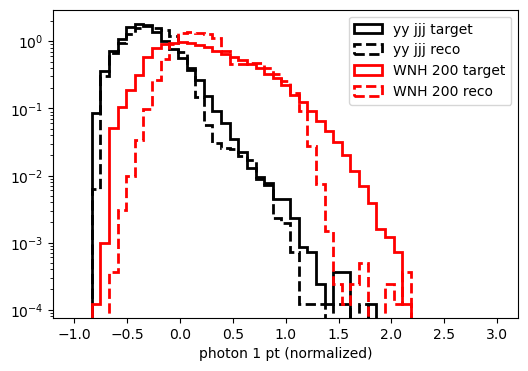

In [8]:
# photon 1 pt
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-1, 3, 50)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, 0, 0], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, 0] > 0.5, validation_features_reco[yy_jjj_mask, 0, 0], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, 0, 0], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, 0] > 0.5, validation_features_reco[wnh_200_mask, 0, 0], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("photon 1 pt (normalized)")
plt.show()


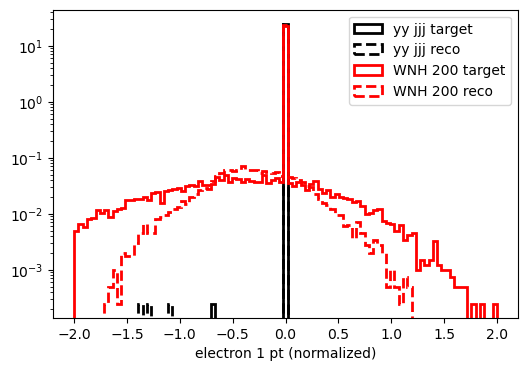

In [9]:
# electron 1 pt
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-2, 2, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, 8, 0], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, 8] > 0.5, validation_features_reco[yy_jjj_mask, 8, 0], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, 8, 0], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, 8] > 0.5, validation_features_reco[wnh_200_mask, 8, 0], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("electron 1 pt (normalized)")
plt.show()


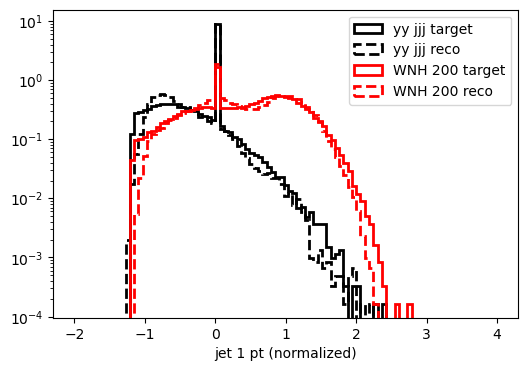

In [10]:
# jet 1 pt
object_index = 2
feature_index = 0
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-2, 4, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("jet 1 pt (normalized)")
plt.show()


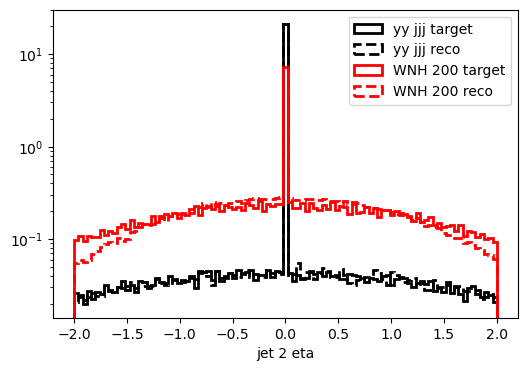

In [11]:
# jet 2 eta
object_index = 3
feature_index = 1
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-2, 2, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("jet 2 eta")
plt.show()


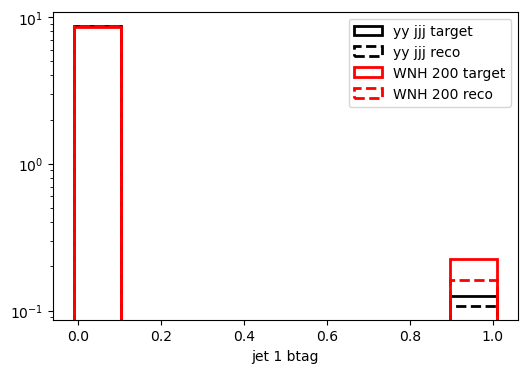

In [12]:
# jet 1 btag
object_index = 2
feature_index = 4
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-0.01, 1.01, 10)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
yy_jjj_present_reco_feature = np.where(yy_jjj_present_reco_feature > 0.5, 1, 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
wnh_200_present_reco_feature = np.where(wnh_200_present_reco_feature > 0.5, 1, 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("jet 1 btag")
plt.show()


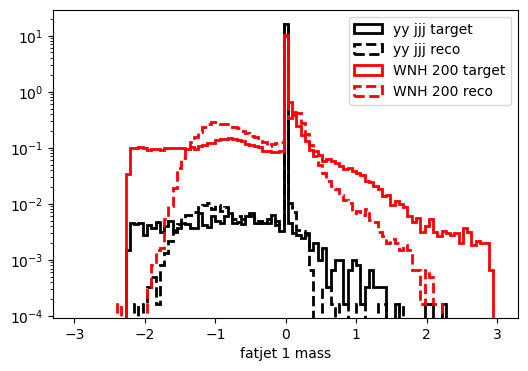

In [13]:
# fatjet 1 mass
object_index = 6
feature_index = 3
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-3, 3, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("fatjet 1 mass")
plt.show()


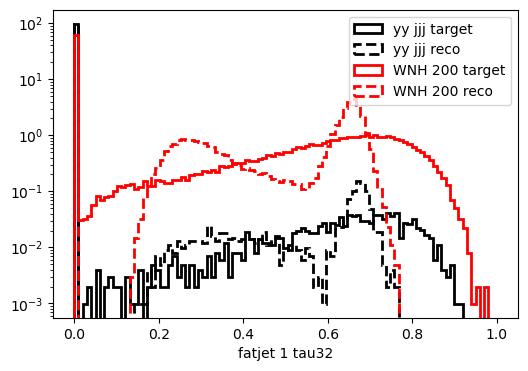

In [14]:
# fatjet 1 tau32
object_index = 6
feature_index = 5
f = plt.figure(figsize=(6, 4))
bins = np.linspace(0, 1, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("fatjet 1 tau32")
plt.show()


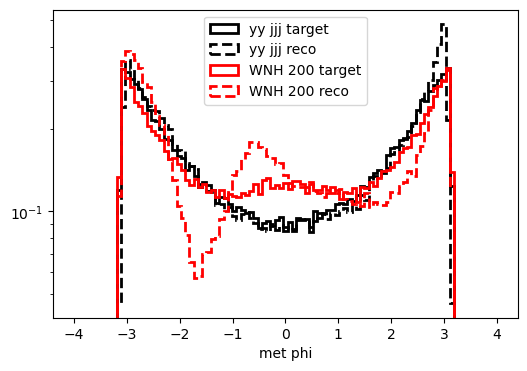

In [15]:
# met phi
object_index = -1
feature_index = 2
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-4, 4, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("met phi")
plt.show()


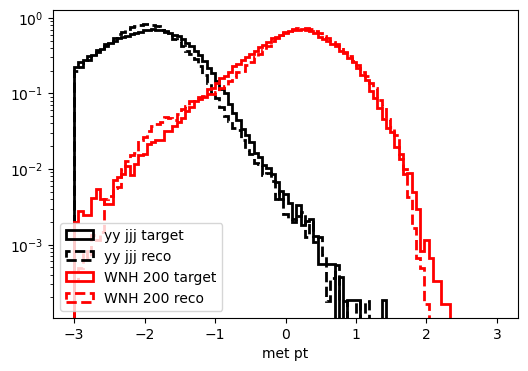

In [16]:
# met pt
object_index = -1
feature_index = 0
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-3, 3, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("met pt")
plt.show()


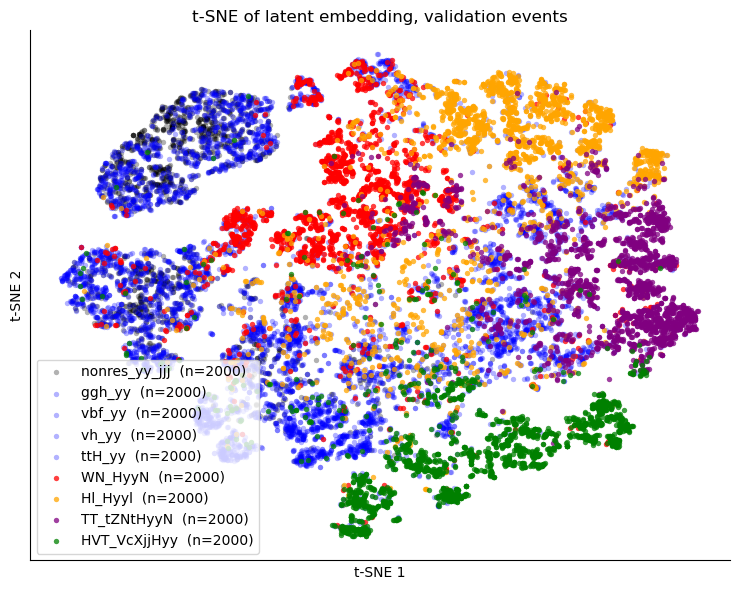

In [17]:
# ── t-SNE of the latent embedding on validation events, coloured by contrastive group ─────────
# Backgrounds (group_id >= 0) in cold colors, signal families (group_id < 0) in warm colors.
from sklearn.manifold import TSNE
from configs.file_dict import process_dict

N_PER_GROUP = 2000          # balanced subsample; t-SNE on ~18k points takes a minute or two on CPU
rng = np.random.default_rng(42)

# 1) latent and group label of the validation set
z = validation_latent_z
y = validation_group_id

# 2) balanced subsample per group so t-SNE is not dominated by the largest class
keep = np.concatenate([
    rng.choice(idx, size=min(N_PER_GROUP, len(idx)), replace=False)
    for gid in np.unique(y)
    for idx in [np.flatnonzero(y == gid)]
])
z_keep, y_keep = z[keep], y[keep]

# 3) t-SNE
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
emb2d = tsne.fit_transform(z_keep)

# 4) plot. Group name = process name without the mass-point suffix (WN_HyyN_150 -> WN_HyyN); backgrounds keep their name.
group_names = {}
for name, entry in process_dict.items():
    group_names.setdefault(entry["group_id"], name if entry["group_id"] >= 0 else "_".join(p for p in name.split("_") if not p.isdigit()))
cold = {0: "black", 1: "blue", 2: "blue", 3: "blue", 4: "blue"}   # SM backgrounds: yyjets, ggH, VBF, VH, ttH
warm = {-1: "red", -2: "orange", -3: "purple", -4: "green"}       # WN_HyyN, Hl_Hyyl, TT_tZNtHyyN, HVT_VcXjjHyy

fig, ax = plt.subplots(figsize=(7.5, 6))
for group, alpha in ((cold, 0.3), (warm, 0.75)):        # backgrounds first, signals drawn on top
    for gid, color in group.items():
        m = y_keep == gid
        if not m.any():
            continue
        ax.scatter(
            emb2d[m, 0], emb2d[m, 1],
            s=15, c=color, alpha=alpha, linewidths=0, rasterized=True,
            label=f"{group_names.get(gid, gid)}  (n={m.sum()})",
        )

ax.set_title("t-SNE of latent embedding, validation events")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()


### per group tSNE

In [18]:
def make_tsne_group(group_id, n_per_background=1500, n_per_process=1500, seed=42):
    """t-SNE of the validation latent for the SM backgrounds plus the individual processes of `group_id`
    (e.g. -1 -> WN_HyyN_150 / 200 / 300 / 600, each in its own warm color)."""
    rng = np.random.default_rng(seed)
    z, gid, pid = validation_latent_z, validation_group_id, validation_process_id
    signal = {name: e["process_id"] for name, e in process_dict.items() if e["group_id"] == group_id}
    background = {name: e["process_id"] for name, e in process_dict.items() if e["group_id"] >= 0}

    # balanced subsample: each background process and each mass point contributes at most n events
    def pick(mask, n):
        idx = np.flatnonzero(mask)
        return rng.choice(idx, size=min(n, len(idx)), replace=False)

    keep = np.concatenate([pick(pid == p, n_per_background) for p in background.values()]
                          + [pick(pid == p, n_per_process) for p in signal.values()])
    emb2d = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=seed).fit_transform(z[keep])
    pid_keep = pid[keep]

    warm = ["#ffd700", "#d62728", "#ff7f0e", "#e377c2", "#8b0000", "#ff1493"]
    fig, ax = plt.subplots(figsize=(7.5, 6))
    for name, p in background.items():                              # backgrounds first, signals drawn on top
        m = pid_keep == p
        if m.any():
            ax.scatter(emb2d[m, 0], emb2d[m, 1], s=15, c="black" if p == 1 else "blue", alpha=0.3,
                       linewidths=0, rasterized=True, label=f"{name}  (n={m.sum()})")
    for color, (name, p) in zip(warm, signal.items()):
        m = pid_keep == p
        if m.any():
            ax.scatter(emb2d[m, 0], emb2d[m, 1], s=15, color=color, alpha=0.8,
                       linewidths=0, rasterized=True, label=f"{name}  (n={m.sum()})")

    ax.set_title(f"t-SNE of latent embedding, validation events, group {group_id}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

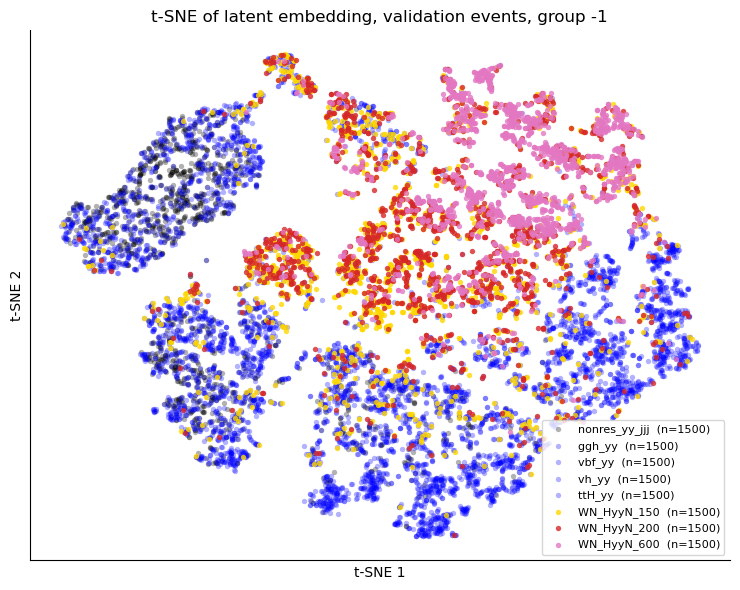

In [19]:
make_tsne_group(-1)

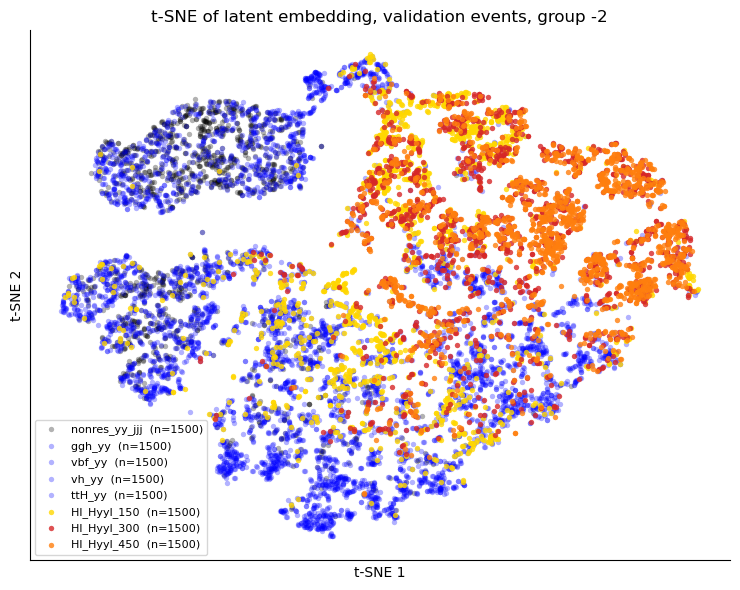

In [20]:
make_tsne_group(-2)

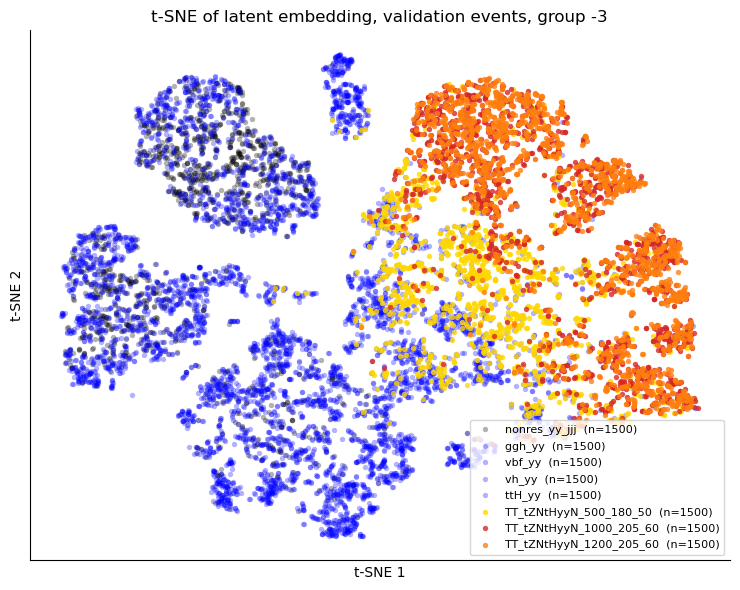

In [21]:
make_tsne_group(-3)

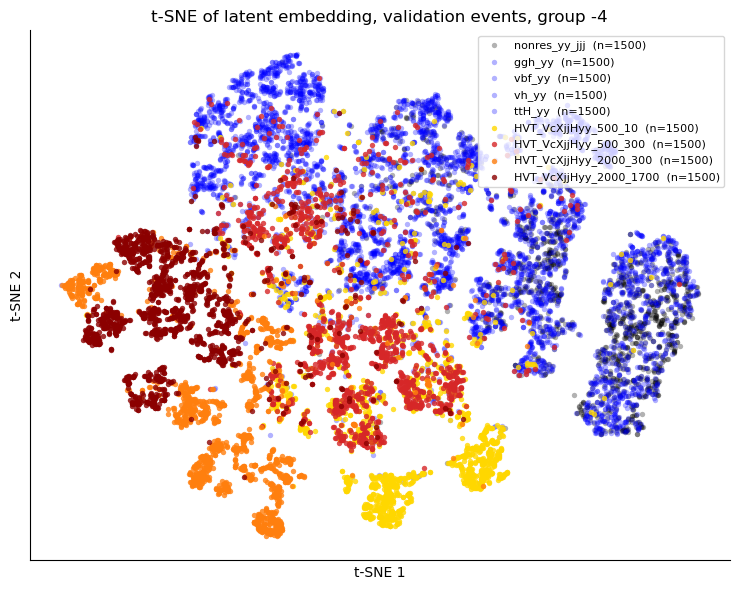

In [22]:
make_tsne_group(-4)

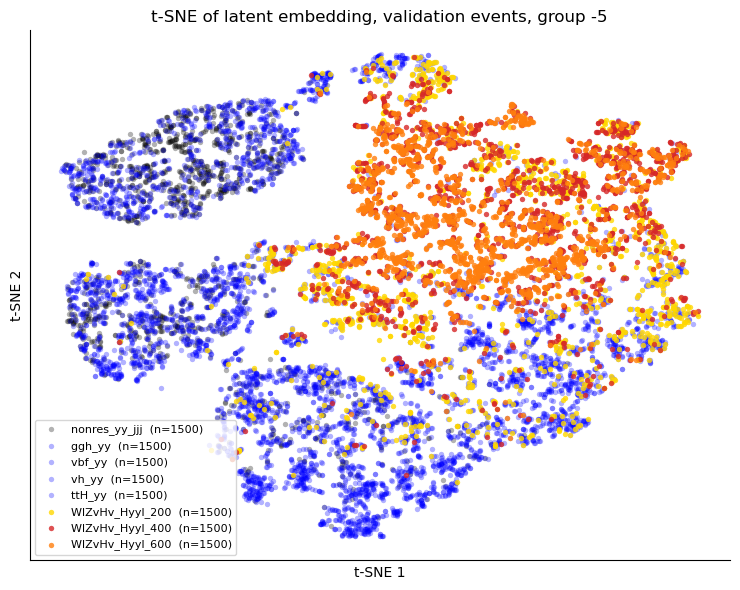

In [23]:
make_tsne_group(-5)

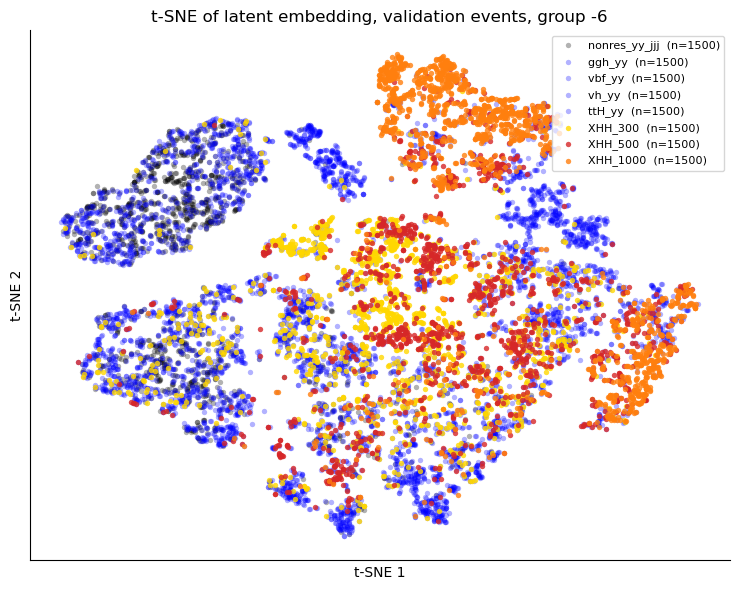

In [24]:
make_tsne_group(-6)

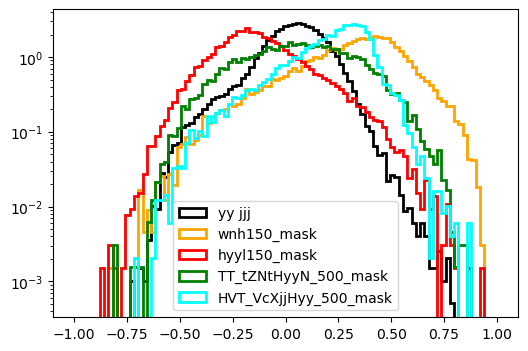

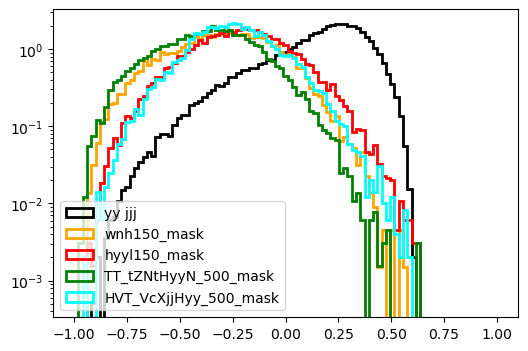

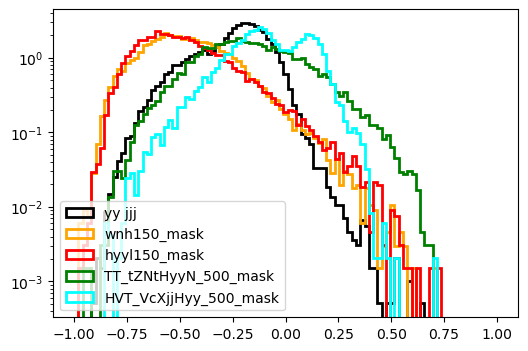

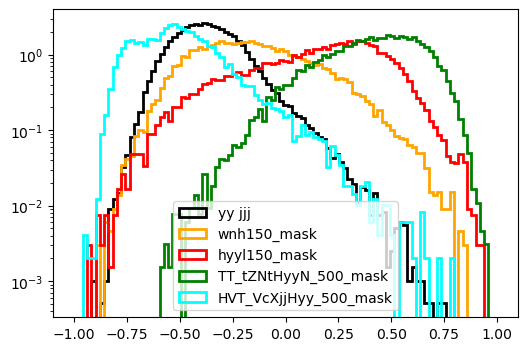

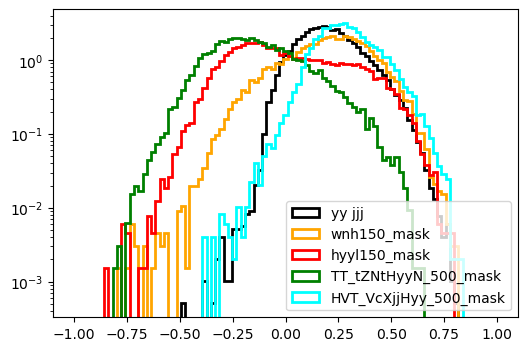

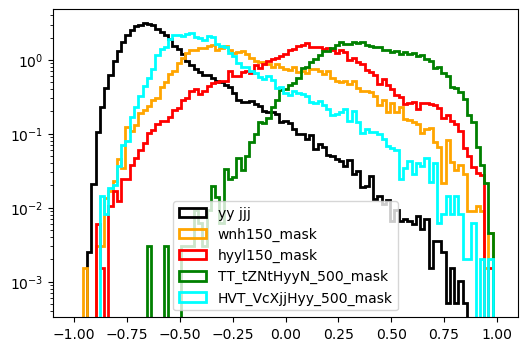

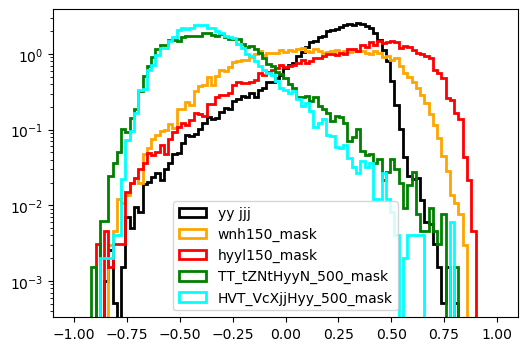

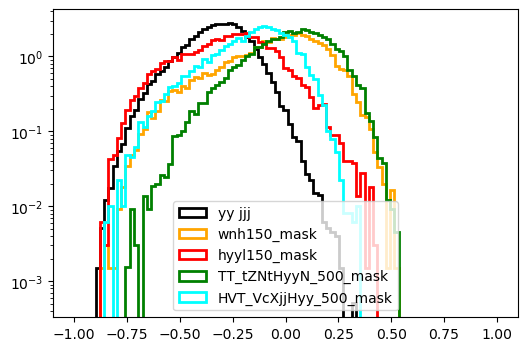

In [19]:
for dim in range(validation_latent_z.shape[1]):
    f = plt.figure(figsize=(6, 4))

    bins = np.linspace(-1, 1, 100)  # z is L2-normalized in the encoder, so every component lies in [-1, 1]
    yy_jjj_mask = validation_process_id == 1
    plt.hist(validation_latent_z[yy_jjj_mask, dim], bins=bins, histtype='step', label="yy jjj", density=True, linewidth=2, color="black")

    wnh150_mask = validation_process_id == -1
    plt.hist(validation_latent_z[wnh150_mask, dim], bins=bins, histtype='step', label="wnh150_mask", density=True, linewidth=2, color="orange")

    hyyl150_mask = validation_process_id == -5
    plt.hist(validation_latent_z[hyyl150_mask, dim], bins=bins, histtype='step', label="hyyl150_mask", density=True, linewidth=2, color="red")

    TT_tZNtHyyN_500_mask = validation_process_id == -8
    plt.hist(validation_latent_z[TT_tZNtHyyN_500_mask, dim], bins=bins, histtype='step', label="TT_tZNtHyyN_500_mask", density=True, linewidth=2, color="green")

    HVT_VcXjjHyy_500_mask = validation_process_id == -11
    plt.hist(validation_latent_z[HVT_VcXjjHyy_500_mask, dim], bins=bins, histtype='step', label="HVT_VcXjjHyy_500_mask", density=True, linewidth=2, color="cyan")
    
    plt.yscale("log")
    plt.legend()
    plt.show()
    